# 03 · Backfill condicional y construcción del dataset final

Con los 4 pools sintéticos del notebook 02 (muestras conjuntas
`[retorno, features intradía]` sin condicionar), este notebook rellena
los **~24 años sin barras de 5 min reales** (1996-05 → 2020-10) de los 25
bancos del predictor:
para cada día histórico se conoce el retorno diario REAL (Norgate) y se
le empareja, por "conditional matching" (vecino más cercano ponderado por
un kernel gaussiano sobre la distancia en retorno, ver
`src/backfill.py`), una muestra de features intradía del pool sintético
correspondiente.

El resultado son 4 datasets completos de 30 años (~5,5 reales + ~24,5
sintéticos), uno por generador, listos para la rejilla de entrenamiento
del notebook 04.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

# Recarga automatica de src/ al editarlo: sin esto, si se edita un modulo
# de src/ con el kernel ya arrancado, Jupyter sigue usando la version que
# importo la primera vez (y aparecen errores tipo "unexpected keyword
# argument" con codigo que en disco si es correcto).
try:
    ip = get_ipython()
    ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")
except NameError:
    pass  # ejecutandose fuera de IPython/Jupyter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import backfill as bf, config, data_norgate as dn, features as feat, plotting as pl

## 1. Cargar retornos reales (25 bancos, 30 años) y features intradía
   reales (desde 2020-11, ~5,5 años)

In [2]:
returns_predictor = pd.read_parquet(config.INTERIM_DIR / "returns_predictor.parquet")
returns_predictor = returns_predictor[returns_predictor.index >= pd.Timestamp(config.TOTAL_HISTORY_START_DATE)]
print("retornos reales:", returns_predictor.shape, returns_predictor.index.min(), "->", returns_predictor.index.max())

intraday_long = pd.read_parquet(config.INTERIM_DIR / "intraday_features_real.parquet")
real_intraday_feats = {
    tk: g.set_index("date")[feat.INTRADAY_FEATURE_COLS]
    for tk, g in intraday_long[intraday_long["ticker"].isin(config.PREDICTOR_TICKERS)].groupby("ticker")
}
print(f"features intradia reales disponibles para {len(real_intraday_feats)}/{config.N_PREDICTOR_TICKERS} bancos del predictor")

retornos reales: (7387, 25) 1996-05-29 00:00:00 -> 2026-05-29 00:00:00
features intradia reales disponibles para 25/25 bancos del predictor


## 2. Cargar los 4 pools sintéticos del notebook 02

In [3]:
synthetic_pools = {}
for name in ["noise", "gaussian", "rbig", "gan"]:
    path = config.INTERIM_DIR / f"synthetic_pool_{name}.npy"
    if path.exists():
        synthetic_pools[name] = np.load(path)
print("generadores disponibles:", list(synthetic_pools.keys()))
assert len(synthetic_pools) >= 3, "Faltan pools sinteticos del notebook 02 (ejecutalo primero)"

generadores disponibles: ['noise', 'gaussian', 'rbig', 'gan']


## 3. Backfill condicional: un panel de volatilidad realizada de 30 años
   por generador

In [4]:
full_history_by_generator = {}
rv_panel_by_generator = {}
for name, pool in synthetic_pools.items():
    full_hist = bf.build_full_history_features(
        returns_predictor, real_intraday_feats, pool,
        real_start=config.REAL_INTRADAY_START_DATE, k_neighbors=80, random_state=config.RANDOM_SEED,
    )
    full_history_by_generator[name] = full_hist
    rv_panel_by_generator[name] = bf.rv_panel_from_full_history(full_hist)
    n_synth_days = int(full_hist[config.PREDICTOR_TICKERS[0]]["is_synthetic"].sum())
    print(f"{name}: panel {rv_panel_by_generator[name].shape}, "
          f"{n_synth_days} dias sinteticos por ticker (de {len(full_hist[config.PREDICTOR_TICKERS[0]])})")

noise: panel (7387, 25), 5988 dias sinteticos por ticker (de 7387)
gaussian: panel (7387, 25), 5988 dias sinteticos por ticker (de 7387)
rbig: panel (7387, 25), 5988 dias sinteticos por ticker (de 7387)
gan: panel (7387, 25), 5988 dias sinteticos por ticker (de 7387)


## 4. Validación visual: la serie de volatilidad, 30 años, real + sintética

Un banco de ejemplo (JPM): tramo sintético (~24 años, gris) + tramo real
(~5,5 años, color) para los 4 generadores. Lo importante no es que la
parte sintética "acierte" día a día (es imposible sin datos reales), sino
que el NIVEL y la VARIABILIDAD sean coherentes con el tramo real, sin
saltos artificiales en el empalme.

WindowsPath('C:/Users/Natalia/workplace/Taller-B5-T1-Generativos/reports/figures/03_backfill_serie_temporal_JPM.png')

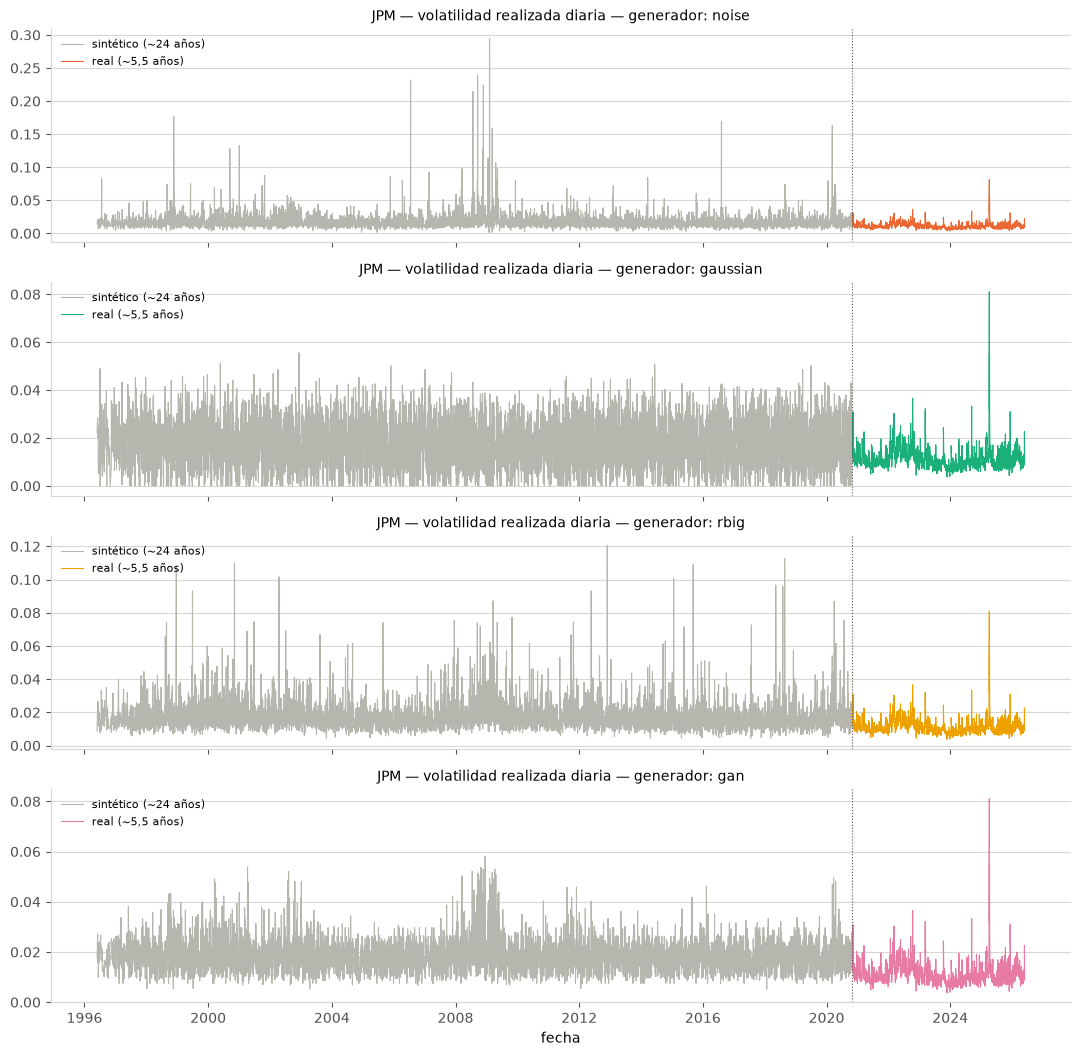

In [5]:
demo_ticker = "JPM"
generadores_demo = [n for n in ["noise", "gaussian", "rbig", "gan"] if n in full_history_by_generator]
fig, axes = plt.subplots(len(generadores_demo), 1, figsize=(11, 8 / 3 * len(generadores_demo)), sharex=True)
for ax, name in zip(axes, generadores_demo):
    panel = full_history_by_generator[name][demo_ticker]
    is_synth = panel["is_synthetic"]
    ax.plot(panel.index[is_synth], panel.loc[is_synth, "realized_vol"],
            color="#b7b6ae", linewidth=0.8, label="sintético (~24 años)")
    ax.plot(panel.index[~is_synth], panel.loc[~is_synth, "realized_vol"],
            color=pl.color_for(name), linewidth=0.8, label="real (~5,5 años)")
    ax.axvline(pd.Timestamp(config.REAL_INTRADAY_START_DATE), color="#52514e", linewidth=0.8, linestyle=":")
    ax.set_title(f"{demo_ticker} — volatilidad realizada diaria — generador: {name}", fontsize=10)
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    pl.style_axes(ax)
axes[-1].set_xlabel("fecha")
fig.tight_layout()
pl.savefig(fig, "03_backfill_serie_temporal_JPM")

## 5. Comprobación de continuidad en el empalme (~5,5 años reales / ~24
   sintéticos)

Para cada generador y cada banco, ratio entre el nivel medio de
volatilidad sintética (últimos 2 años de la parte sintética, justo antes
del empalme) y el nivel medio real (primeros 2 años de la parte real,
justo después). Un ratio cercano a 1 indica que no hay salto artificial.

In [6]:
rows = []
cutoff = pd.Timestamp(config.REAL_INTRADAY_START_DATE)
for name, full_hist in full_history_by_generator.items():
    for tk, panel in full_hist.items():
        synth_tail = panel.loc[(panel.index < cutoff) & (panel.index >= cutoff - pd.Timedelta(days=730)), "realized_vol"]
        real_head = panel.loc[(panel.index >= cutoff) & (panel.index < cutoff + pd.Timedelta(days=730)), "realized_vol"]
        if len(synth_tail) and len(real_head):
            rows.append({"generador": name, "ticker": tk, "ratio_empalme": synth_tail.mean() / real_head.mean()})

empalme = pd.DataFrame(rows).groupby("generador")["ratio_empalme"].agg(["mean", "std"])
empalme.to_csv(config.TABLES_DIR / "03_continuidad_empalme.csv")
empalme

,mean,std
generador,,
gan,1.235160,0.104902
gaussian,1.168996,0.112297
noise,1.196247,0.091995
rbig,1.183870,0.103704


## 6. Dataset final por generador: ventanas X/Y de 30 años

`X`: ventana de `WINDOW_X_DAYS` días con, por banco, [retorno diario,
volatilidad realizada (real o sintética según la fecha)]. `Y`: retorno del
**día siguiente** por banco (`WINDOW_Y_DAYS=1`).

In [7]:
datasets_by_generator = {}
for name, rv_panel in rv_panel_by_generator.items():
    combined = pd.concat(
        [returns_predictor[config.PREDICTOR_TICKERS],
         rv_panel[config.PREDICTOR_TICKERS].add_suffix("_rv")],
        axis=1,
    ).dropna()
    X, Y_wide, idx = feat.build_xy_windows(combined, config.WINDOW_X_DAYS, config.WINDOW_Y_DAYS)
    Y = Y_wide[:, : config.N_PREDICTOR_TICKERS]  # solo retornos, no la parte "_rv" de Y
    # Targets a 7 y 30 dias sobre LAS MISMAS ventanas X. Se calculan aqui,
    # con `combined` a mano, porque el .dropna() de arriba quita filas y la
    # aritmetica posicional solo cuadra contra ESE panel, no contra
    # `returns_predictor` a secas. X no depende del horizonte: es la misma
    # ventana de 60 dias termine donde termine el target.
    targets = {}
    for h in config.HORIZONTES_DIAS:
        targets[f"Y_h{h}"] = (
            Y if h == config.WINDOW_Y_DAYS
            else feat.target_media_futura(combined, idx, h, config.PREDICTOR_TICKERS)
        )
    is_synthetic = np.asarray(idx < cutoff)
    datasets_by_generator[name] = (X, Y, idx, is_synthetic, targets)
    print(f"{name}: X {X.shape}  Y {Y.shape}  rango {idx.min().date()} -> {idx.max().date()}  "
          f"({is_synthetic.mean():.1%} de las filas con volatilidad sintetica en algun punto)")
    for h, Yh in targets.items():
        print(f"    {h}: {int((~np.isnan(Yh).any(axis=1)).sum())} ventanas con target valido")

noise: X (7322, 60, 50)  Y (7322, 25)  rango 1996-12-09 -> 2026-05-27  (81.0% de las filas con volatilidad sintetica en algun punto)
    Y_h1: 7322 ventanas con target valido
    Y_h7: 7317 ventanas con target valido
    Y_h30: 7294 ventanas con target valido
gaussian: X (7322, 60, 50)  Y (7322, 25)  rango 1996-12-09 -> 2026-05-27  (81.0% de las filas con volatilidad sintetica en algun punto)
    Y_h1: 7322 ventanas con target valido
    Y_h7: 7317 ventanas con target valido
    Y_h30: 7294 ventanas con target valido
rbig: X (7322, 60, 50)  Y (7322, 25)  rango 1996-12-09 -> 2026-05-27  (81.0% de las filas con volatilidad sintetica en algun punto)
    Y_h1: 7322 ventanas con target valido
    Y_h7: 7317 ventanas con target valido
    Y_h30: 7294 ventanas con target valido
gan: X (7322, 60, 50)  Y (7322, 25)  rango 1996-12-09 -> 2026-05-27  (81.0% de las filas con volatilidad sintetica en algun punto)
    Y_h1: 7322 ventanas con target valido
    Y_h7: 7317 ventanas con target valido
   

## 7. Guardar (`datos/interim/`, gitignored)

In [8]:
for name, (X, Y, idx, is_synthetic, targets) in datasets_by_generator.items():
    np.savez(
        config.INTERIM_DIR / f"dataset_{name}.npz",
        X=X, Y=Y, idx=idx.values.astype("datetime64[ns]"), is_synthetic=is_synthetic,
        **targets,
    )
print("Guardados:", [f"dataset_{n}.npz" for n in datasets_by_generator])

Guardados: ['dataset_noise.npz', 'dataset_gaussian.npz', 'dataset_rbig.npz', 'dataset_gan.npz']


## 8. Anexo · hiperparametros ganadores de la busqueda

El mismo backfill condicional, mismos `k=80` vecinos, mismo kernel, misma
semilla, alimentado con los pools de los generadores optimizados del
anexo del notebook 02:

```bash
python scripts/figuras_backfill_hpbest.py --datos <ruta>/datos
```

![Backfill de JPM con generadores optimizados](../reports/figures/03_backfill_serie_temporal_JPM_hpbest.png)

| Generador | ratio de empalme | desv. entre bancos | autocorr. sintética | autocorr. real |
|---|---|---|---|---|
| Ruido | 1.196 | 0.106 | 0.081 | 0.588 |
| Gaussiana | 1.145 | 0.117 | -0.004 | 0.588 |
| RBIG | 1.186 | 0.101 | 0.082 | 0.588 |
| GAN | 1.025 | 0.083 | 0.117 | 0.588 |

Tres lecturas:

1. **La Gaussiana deja de ser una banda plana.** Con la configuracion de
   clase su volatilidad sintetica no tenia colas, asi que los ~24 anios
   salian sin crisis; con `rank_gauss` conserva las marginales reales y
   vuelven a aparecer picos. RBIG ensena además un racimo claro en
   2008-09.
2. **El empalme no mejora.** El nivel sintético sigue un 15-20% por
   encima del real inmediatamente posterior. Ese sesgo no lo arregla el
   generador porque no viene solo de el: la ventana de medida sintética
   (nov-2018 → oct-2020) incluye el COVID y la real de despues es la
   recuperación, y además el pool son 150 bancos, muchos pequenos y
   volatiles, frente a los 25 grandes supervivientes del predictor.
3. **La persistencia sigue rota.** La autocorrelación a un día del tramo
   sintetico se queda muy por debajo de la del tramo real, con cualquier
   generador. Es la consecuencia directa de muestrear cada día de forma
   independiente: no es un defecto del generador, sino del mecanismo de
   condicionamiento (ver `v2_persistencia_temporal/`, que lo corrige
   condicionando tambien a la volatilidad del día anterior).